PART ONE: Data Loading and Cleaning

In [146]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv(r"C:\Users\njedr\Downloads\Palmer Penguins Dataset\Palmer Penguins Dataset.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [152]:
df.shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 344
Number of columns: 8


In [153]:
df.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.00,342.00,342.00,342.00,344.00
mean,43.92,17.15,200.92,4201.75,2008.03
std,5.46,1.97,14.06,801.95,0.82
min,32.10,13.10,172.00,2700.00,2007.00
25%,39.22,15.60,190.00,3550.00,2007.00
50%,44.45,17.30,197.00,4050.00,2008.00
75%,48.50,18.70,213.00,4750.00,2009.00
max,59.60,21.50,231.00,6300.00,2009.00


In [155]:
df['year'] = df['year'].astype('category')
# year set as category since it is a discrete variable representing specific years, not a continuous numerical value and not give 
df.describe() 

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

column sex has 11 missing values,and bil-length, bill-depth and nody-mass have 2 each.

In [156]:
df['sex'].value_counts()

sex
male      168
female    165
Name: count, dtype: int64

since the difference between male and female is only 3, with missing values of 11, NaN will be filled with 'unknown', to avoid inflating values or getting it skewed

In [157]:
df['sex']= df['sex'].fillna('Unknown')
print(df['sex'].value_counts())
miss_value=df['sex'].isnull().sum()
print(f"Number of missing values in sex column: {miss_value}")

sex
male       168
female     165
Unknown     11
Name: count, dtype: int64
Number of missing values in sex column: 0


In [172]:
print(df[df['bill_length_mm'].isnull()])

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
3    Adelie  Torgersen             NaN            NaN                NaN   
271  Gentoo     Biscoe             NaN            NaN                NaN   

     body_mass_g      sex  year  
3            NaN  Unknown  2007  
271          NaN  Unknown  2009  


since all the other missing values are on these two role, the best choice is to drop them

In [173]:
df=df.drop(df[df['bill_length_mm'].isnull()].index)

In [176]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

In [177]:
df.duplicated().sum()  

np.int64(0)

since there are no duplicates, we can proceed with the analysis without needing to remove any rows.

PART TWO: Exploratory Data Analysis (EDA)

In [178]:
df.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


This table summarizes the numerical columns of the Penguins dataset with their various means,count(number of roles), standard deviation, minimum(min) and maximum(max) values, median(50%) and the 75 and 25 qauntiles.

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            342 non-null    object  
 1   island             342 non-null    object  
 2   bill_length_mm     342 non-null    float64 
 3   bill_depth_mm      342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                342 non-null    object  
 7   year               342 non-null    category
dtypes: category(1), float64(4), object(3)
memory usage: 21.8+ KB


This table list the columns in the Palmer Penguins Dataset and the sum of non-null values and their type of data



In [180]:
print(df['species'].unique())
print(df['species'].value_counts())



['Adelie' 'Gentoo' 'Chinstrap']
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


In [181]:
print(df['island'].unique())
print(df['island'].value_counts())



['Torgersen' 'Biscoe' 'Dream']
island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64


In [182]:
print(df['sex'].unique())
print(df['sex'].value_counts())


['male' 'female' 'Unknown']
sex
male       168
female     165
Unknown      9
Name: count, dtype: int64


In [183]:

print(df['year'].unique())  
print(df['year'].value_counts())

[2007, 2008, 2009]
Categories (3, int64): [2007, 2008, 2009]
year
2009    119
2008    114
2007    109
Name: count, dtype: int64


The immediate 4 tables above give categories under the non-numerical columns

PART 3: Visualization


Text(0.5, 1.0, 'Count of Each Species')

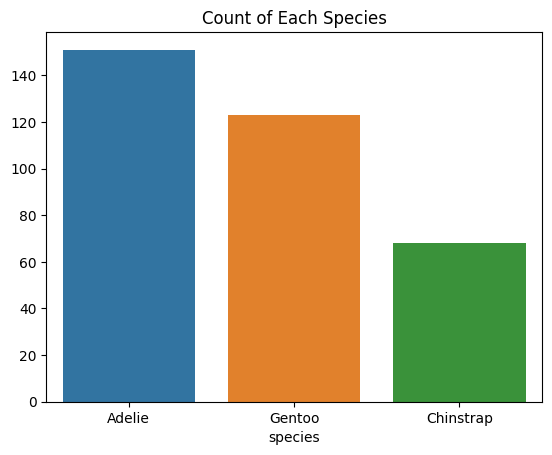

In [185]:
sns.barplot(x=df['species'].value_counts().index, y=df['species'].value_counts().values, hue=df['species'].value_counts().index)
plt.title('Count of Each Species')

Adelie species are the most populated followed by Gentoo and then Chinstrap 

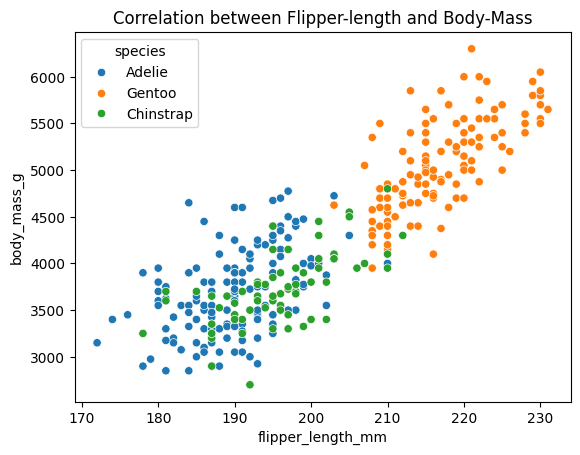

In [186]:
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Correlation between Flipper-length and Body-Mass')
plt.show()

Generally, the flipper length of piguins has a strong positive effect on their body mass. However, Gentoo naturally have big flipper length which separated them from the other two 

In [187]:
df.columns
df.head(20)
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

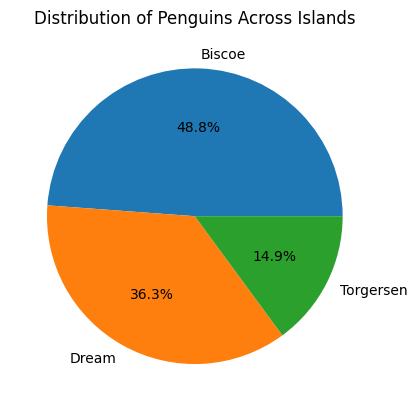

In [188]:
plt.pie(df['island'].value_counts().values, labels = df['island'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribution of Penguins Across Islands')
plt.show()

Majority of the piguins live in Biscoe with 48.8% followed by Dream then Torferson.

Text(0.5, 1.0, 'Distribution of Species by Sex')

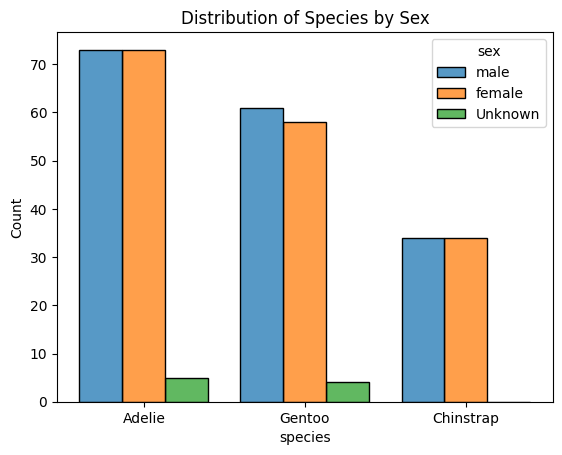

In [189]:
sns.histplot(data =df, x = 'species', hue='sex', multiple='dodge', shrink=0.8)
plt.title('Distribution of Species by Sex')

Generally the male to female ratio is almost one with only Gentoo having a slight margin of male above female. for 'unknown' are the missing values

Text(0.5, 1.0, 'Count of Each Species by Sex')

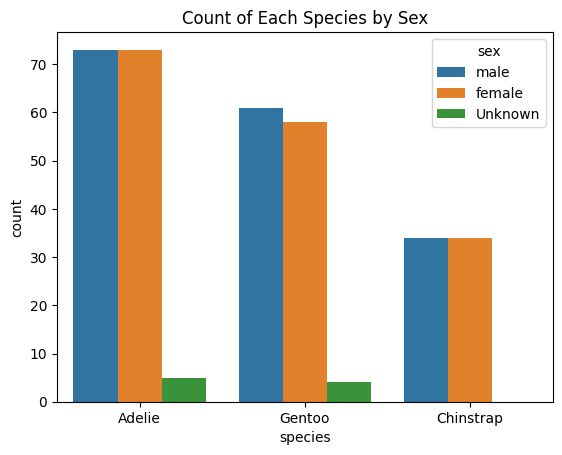

In [190]:
sns.countplot(x=df['species'], hue=df['sex'])
plt.title('Count of Each Species by Sex')

Generally the male to female ratio is almost one with only Gentoo having a slight margin of male above female. for 'unknown' are the missing values

Text(0.5, 1.0, 'Correlation Heatmap')

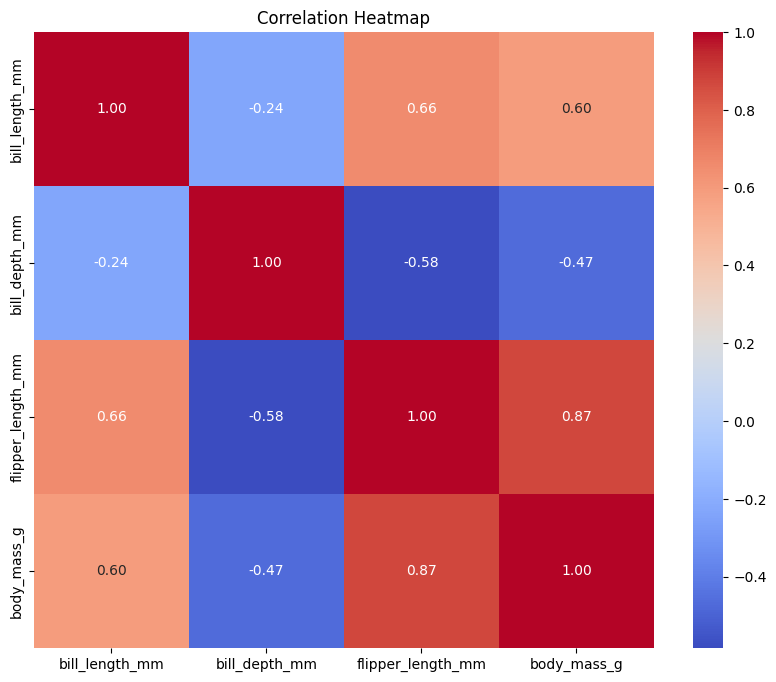

In [191]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')    


From correlation heatmap, bill-depth has a negative correlation with other variables such as bill-length, body-mass and flipper-length.Aside that, the rest of the numerical variables have postive correlation with each other. 

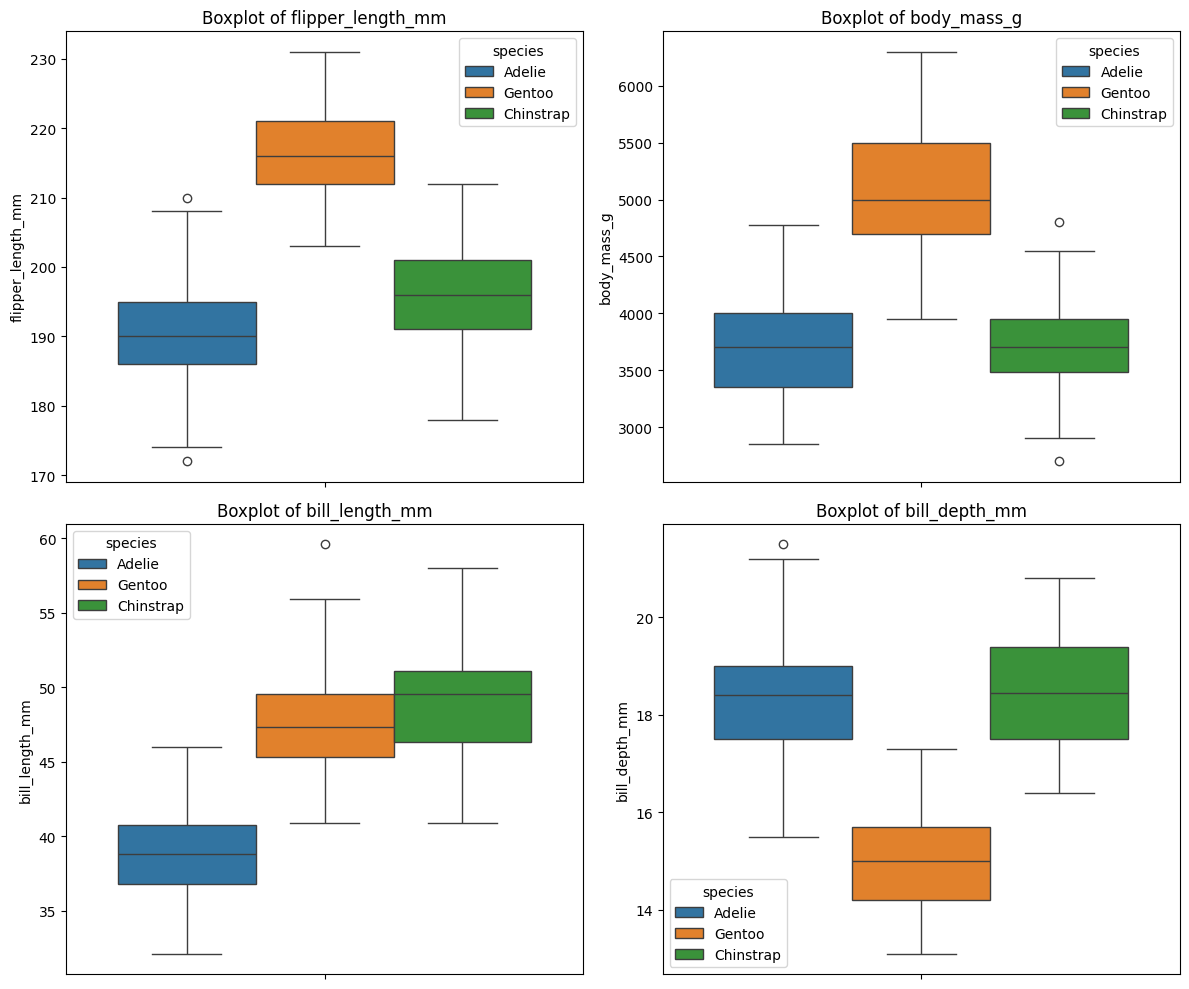

In [192]:
cols= ['flipper_length_mm', 'body_mass_g', 'bill_length_mm', 'bill_depth_mm']
figs, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(data=df,y= col, ax=ax, hue ='species')
    ax.set_title(f'Boxplot of {col}')
    ax.set_xlabel('')
plt.tight_layout()    
plt.show()



From box-plot figure above,it shows there are only few outliers which might have influence of the mean value. It also depicts genrally, the Gentoo species have big flipper length which reflected on the body -mass postively and negatively on the bill_depth.

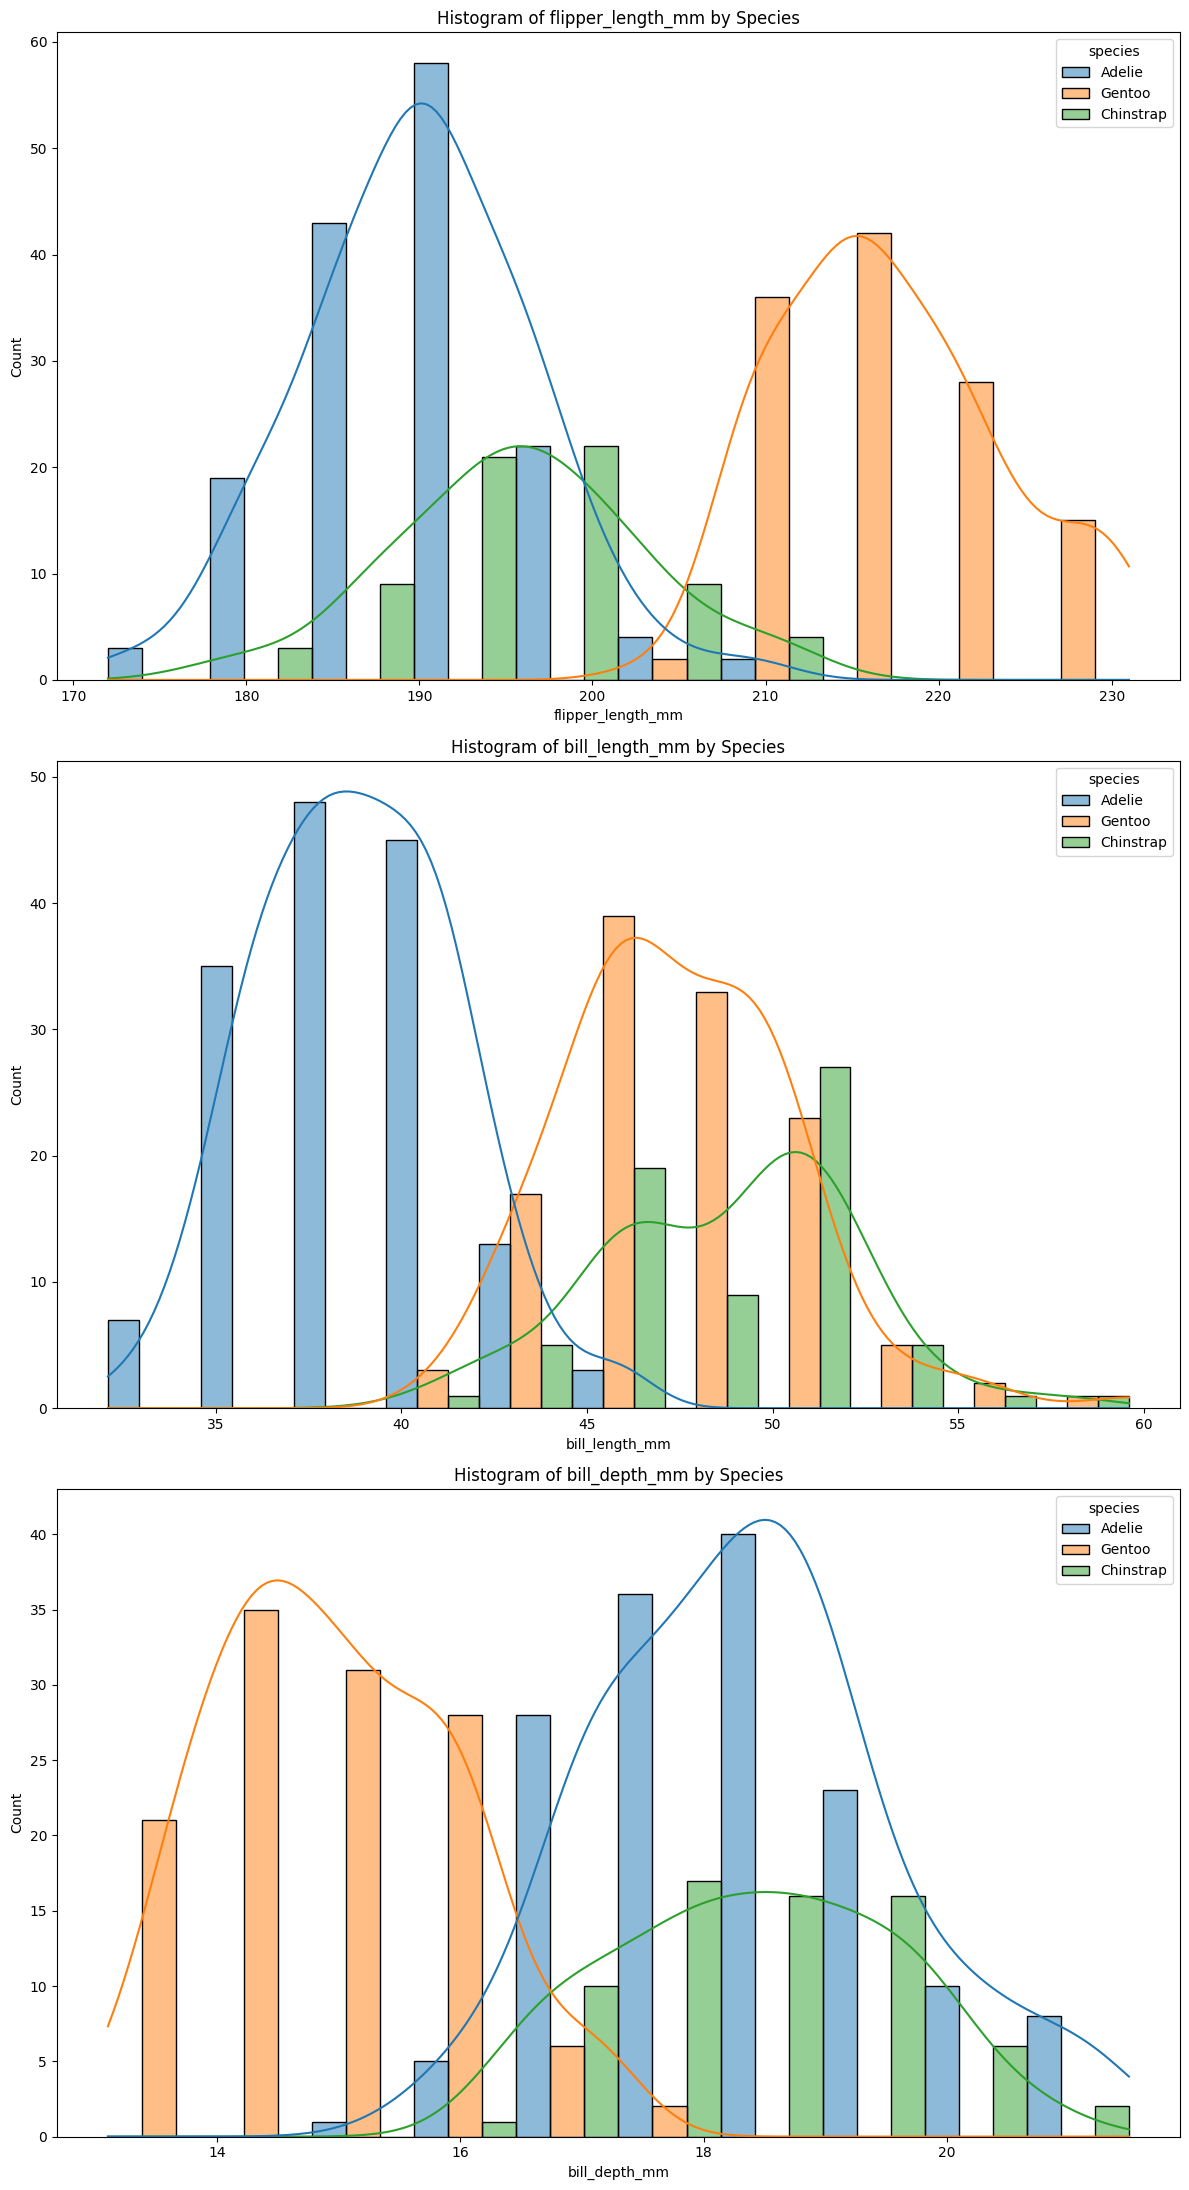

In [193]:
fig, axes = plt.subplots(3, 1, figsize=(12, 22))
cols = ['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(data=df, x=col, hue='species', kde=True, ax=ax, multiple='dodge')
    ax.set_title(f'Histogram of {col} by Species')
plt.tight_layout()
plt.show()

most of the Adelie species have a flipper-length of 190mm, bill-length around 37mm and  bill- depth of 18mm. Most of the Gentoo species tend to have flipper-length, bill-length and depth-length of around 215mm, 41mm and 14.2mm respectively.In summary the Gentoo Species have bigger flipper-length and bill-length and the least bill-depth which is in contrast with the Adelie species.The distribution of the three species seems normal 

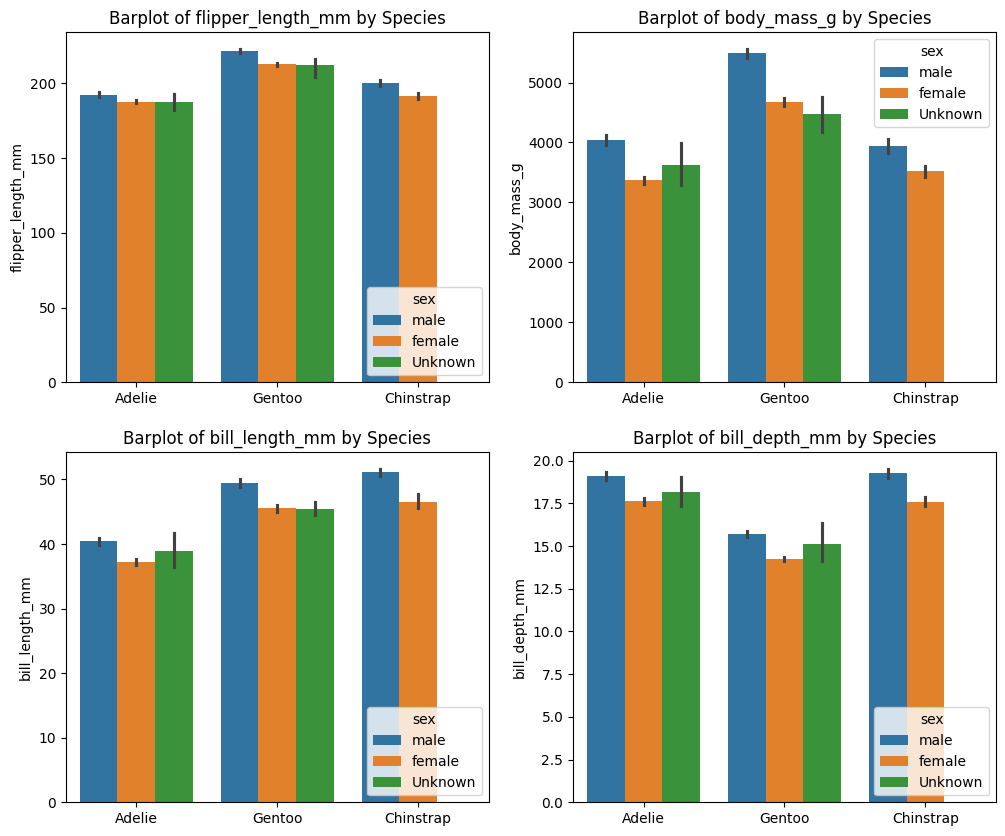

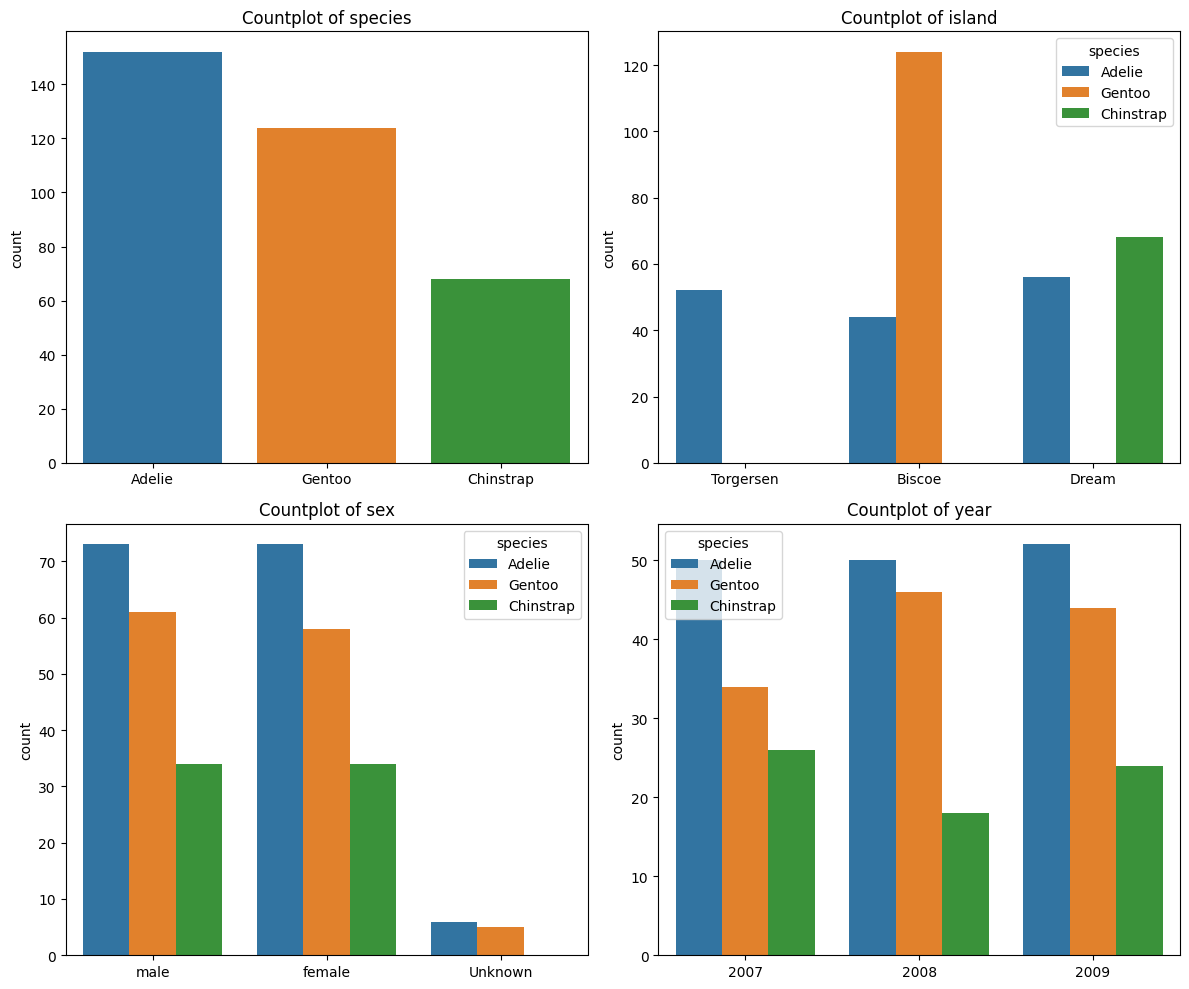

In [139]:
col1= ['flipper_length_mm', 'body_mass_g', 'bill_length_mm', 'bill_depth_mm']
col2 = ['species', 'island', 'sex', 'year']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flatten(), col1):
    sns.barplot(data=df, x='species', y=col, ax=ax, hue ='sex')
    ax.set_title(f'Barplot of {col} by Species')
    ax.set_xlabel('')  
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flatten(), col2):
    sns.countplot(data=df, x=col, ax=ax, hue='species')
    ax.set_title(f'Countplot of {col}')
    ax.set_xlabel('')
plt.tight_layout()  
plt.show()


from the fisrt set graghs, it shows male piguins generally have bigger bill-length, body-mass, bill-depth and flipper-length. With error sticks,it shows the  average values are significant however not the values of unknown because the sample is only 9.

the last sets of graghs show that, the most populated are the Adelie and Torgersen island has only the Adelie species, and Biscoe has only Adelie and Gentoo and Dream having only Adelie and Chinstrap.

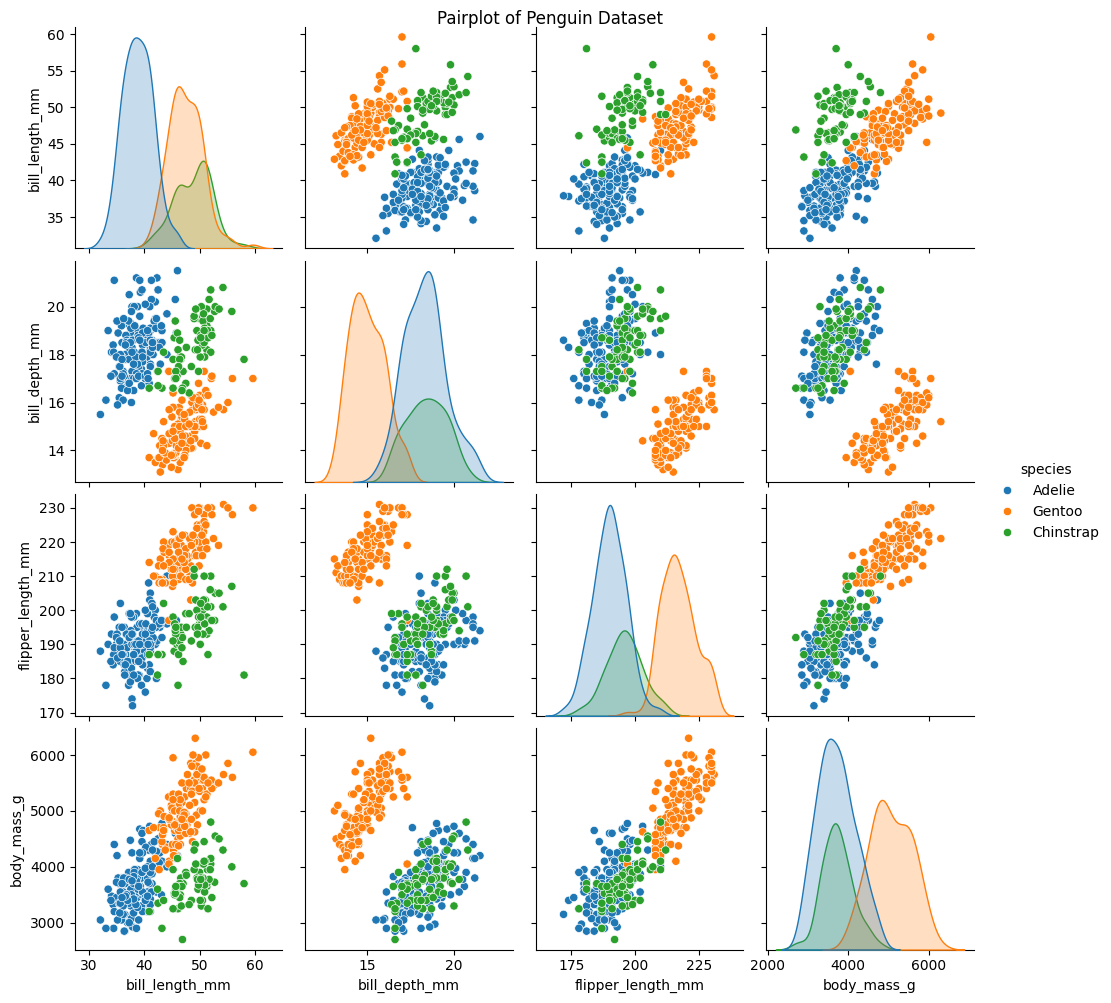

In [142]:
sns.pairplot(data=df, hue='species', diag_kind='kde')
plt.suptitle('Pairplot of Penguin Dataset', y=1.00)
plt.show()

SUMMARY

In summary, the bigger the bill-length and flipper-length, the greater the body-mass ,and lesser if the bill-depth is bigger.
Female piguins tend to have generally smaller body-mass than the male counterpart.
Among the species, The Gentoo species tend to have the biggest body-mass and flipper-length and the Chinstrap having the longest bill-length with intermediate body-masss.